# Baseball Application

We apply our constrained empirical Bayes (EB) denoising methods to a baseball data set, denoising the joint distribution of latent batting skill for rookie players across their final minor-league and first major-league seasons. We focus on runs batted in (RBI) and model each player's RBI counts through a bivariate Poisson likelihood with a games-played exposure.

The notebook is organized into three parts: setting up the data, computing the EB denoisers, and plotting the results. The final figure reproduces the baseball figure in the paper (see the figure-mapping table in the README).

In [1]:
from npeb.PMixture import *
import numpy as np
import pandas as pd
import cvxpy as cp
import itertools
from scipy.linalg import inv, sqrtm
import matplotlib.pyplot as plt
from scipy.spatial import distance_matrix

/Users/aqjaffe/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/aqjaffe/opt/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


## Set up data

The data set is built from publicly available data on [FanGraphs](https://www.fangraphs.com/). A small amount of preprocessing is performed in `data/make_baseball_dataset.ipynb`, and the result is saved to a `.pkl` file that we load below.

In [2]:
rookies = np.load('data/baseball_data.pkl', allow_pickle=True) 
rookies

,Name,minG,minRBI,majG,majRBI
0,Julio Rodriguez,74.0,47.0,132.0,75.0
1,Adley Rutschman,123.0,75.0,113.0,42.0
2,Michael Harris II,101.0,64.0,114.0,64.0
3,Brendan Donovan,108.0,66.0,126.0,45.0
4,Bobby Witt Jr.,123.0,97.0,150.0,80.0
...,...,...,...,...,...
319,Coby Mayo,140.0,99.0,17.0,0.0
320,Trey Lipscomb,129.0,72.0,61.0,10.0
321,Niko Goodrum,65.0,36.0,13.0,0.0
322,Justin Foscue,122.0,84.0,15.0,1.0


In [3]:
Z = np.vstack([rookies['minRBI'].values,rookies['majRBI'].values]).T
L = np.vstack([rookies['minG'].values/142,rookies['majG'].values/162]).T
n = Z.shape[0]

## Compute denoisers

We now compute the three EB denoisers of interest: the unconstrained denoiser, the (marginal) variance-constrained denoiser, and the (marginal) general-constrained denoiser. This uses the `npeb` package, slightly modified to accommodate the bivariate Poisson likelihood.

### Unconstrained empirical Bayes

We fit the bivariate heteroskedastic Poisson NPMLE with `npeb` and form the unconstrained EB posterior-mean denoiser $\hat{\delta}_{\mathcal{B}}$.

In [4]:
eb_model = PMixture()
eb_model.fit_bivariate_heteroskedastic(Z, L)
at, wt = eb_model.get_params()
eb = eb_model.posterior_mean_bivariate_heteroskedastic(Z,L)

M = np.max(eb)
x = np.linspace(0,M)

### Variance-constrained empirical Bayes

We rescale $\hat{\delta}_{\mathcal{B}}$ by the Bures–Wasserstein optimal-transport map that matches the covariance of the denoised data to the estimated covariance of the latent variables, giving $\hat{\delta}_{\mathcal{MVCB}}$ (Algorithm 1).

In [5]:
eb_mean = np.mean(eb,axis=0)
M_hat = (eb-eb_mean).T@(eb-eb_mean)/n
mu_hat = np.sum(at * wt.reshape(-1,1), axis=0)
A_hat = (at - mu_hat).T @ np.diag(wt) @ (at - mu_hat)
transport_hat = inv(sqrtm(M_hat))@sqrtm(sqrtm(M_hat)@A_hat@sqrtm(M_hat))@inv(sqrtm(M_hat))
emvcb = (eb - eb_mean)@transport_hat + mu_hat

### General-constrained empirical Bayes

We solve the linear program that matches the first two moments of the denoised data to those of the latent variables, subject to two support constraints on the denoised skills: component-wise nonnegativity, and the requirement that no player's denoised major-league skill exceed their minor-league skill. The latter restricts the support to the region on or below the diagonal (major $\le$ minor) and is imposed in the code by keeping only grid atoms with `Eta[:,0] >= Eta[:,1]` (column 0 is minor-league skill, column 1 is major-league skill). We then take the barycentric projection to obtain $\hat{\delta}_{\mathcal{MGCB}}$ (Algorithm 3).

In [6]:
M_min = 1.1*np.max(emvcb[:,0])
m_maj = 1.3*np.min(emvcb[:,1])
M_maj = 1.1*np.max(emvcb[:,1])
x = np.linspace(0,M_min)

In [7]:
k = 100
emgcb_min_min, emgcb_min_max = 0.8*np.min(emvcb[:,0]), 1.2*np.max(emvcb[:,0])
emgcb_maj_min, emgcb_maj_max = 0, 1.2*np.max(emvcb[:,1])

Eta_min = np.linspace(emgcb_min_min,emgcb_min_max,k)
Eta_maj = np.linspace(emgcb_maj_min,emgcb_maj_max,k)

Eta = np.array(list(itertools.product(Eta_min,Eta_maj)))
Eta = np.vstack([Eta, at[wt>0.01]])
# Eta = np.array([pt for pt in  if pt[0] >= pt[1]])
Eta = Eta[Eta[:,0]>=Eta[:,1]]


In [8]:
pi = cp.Variable((n,Eta.shape[0]))
C_hat = distance_matrix(eb, Eta)**2
objv = cp.Minimize(cp.sum(cp.multiply(C_hat, pi)))
emgcb = np.zeros((n,2))
H = cp.sum(pi, axis=0)

# LP constraints: valid coupling with uniform Z-marginal, matching the first two moments
cstr = [pi >= 0, cp.sum(pi) == 1,
        cp.sum(pi, axis=1) == np.ones(n)/n,
        Eta.T @ H == mu_hat,
        (Eta - mu_hat).T @ cp.diag(H) @ (Eta - mu_hat) == A_hat]
problem = cp.Problem(objv,cstr)
problem.solve(solver='MOSEK',verbose=False)
pi_opt = pi.value
# barycentric projection of the optimal coupling
for i in range(n):
    emgcb[i,:] = (pi_opt[i,:].reshape(1,-1) @ Eta) / np.sum(pi_opt[i,:])

## Plot

Finally, we plot the exposure-standardized observations alongside the unconstrained, variance-constrained, and general-constrained EB denoised data sets. The dashed lines mark the diagonal (equal minor- and major-league skill) and the horizontal axis.

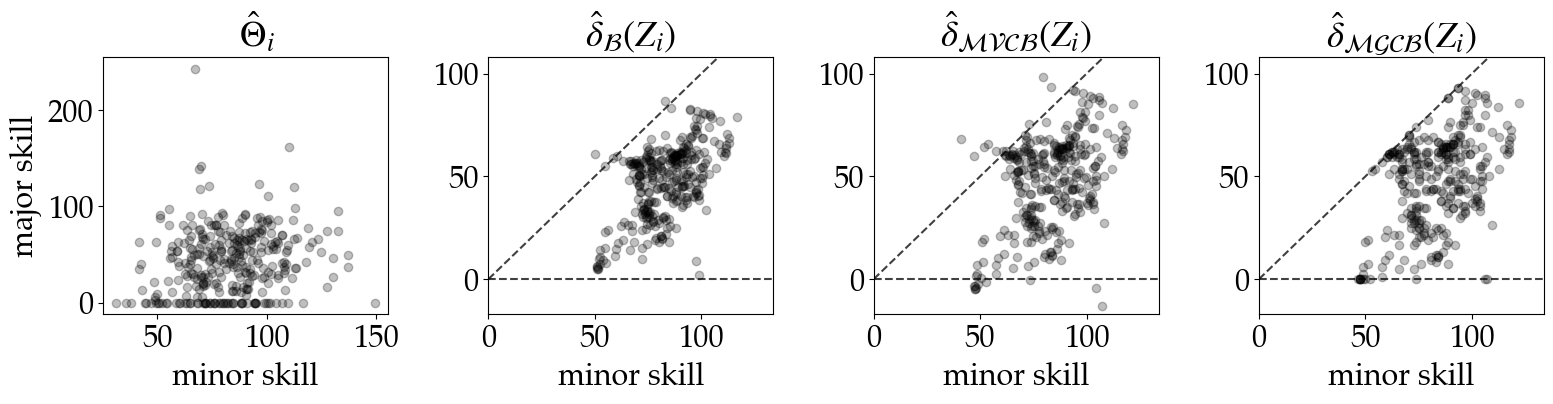

In [9]:
plt.rcParams.update({'font.size': 22,
                     'mathtext.fontset': 'stix',
                     'font.family': 'serif',
                     'font.serif':'Palatino'})


fig, ax = plt.subplots(1, 4, sharex=False, sharey=False, figsize=(16,4.5))

ax[0].set_title('$\\hat{\\,\\,\\,\\,\\,\\Theta_i}$')
ax[0].set_ylabel('major skill')
ax[0].set_xlabel('minor skill')
ax[0].scatter(rookies['minRBI']/(rookies['minG']/142),rookies['majRBI']/(rookies['majG']/162), alpha=0.25, color='black')

ax[1].set_title('$\\hat{\\delta}_{\mathcal{B}}(Z_i)$')
ax[1].set_xlabel('minor skill')
ax[1].scatter(eb[:,0], eb[:,1], alpha=0.25, color='black')
ax[1].plot(x,x,color='black',linestyle='dashed',alpha=0.75)
ax[1].plot(x,np.zeros_like(x),color='black',linestyle='dashed',alpha=0.75)
ax[1].set_xlim([0,M_min])
ax[1].set_ylim([m_maj,M_maj])

ax[2].set_title('$\\hat{\\delta}_{\mathcal{MVCB}}(Z_i)$')
ax[2].set_xlabel('minor skill')
ax[2].scatter(emvcb[:,0], emvcb[:,1], alpha=0.25, color='black')
ax[2].plot(x,x,color='black',linestyle='dashed',alpha=0.75)
ax[2].plot(x,np.zeros_like(x),color='black',linestyle='dashed',alpha=0.75)
ax[2].sharex(ax[1])
ax[2].sharey(ax[1])

ax[3].set_title('$\\hat{\\delta}_{\mathcal{MGCB}}(Z_i)$')
ax[3].set_xlabel('minor skill')
ax[3].scatter(emgcb[:,0], emgcb[:,1], alpha=0.25, color='black')
ax[3].plot(x,x,color='black',linestyle='dashed',alpha=0.75)
ax[3].plot(x,np.zeros_like(x),color='black',linestyle='dashed',alpha=0.75)
ax[3].sharex(ax[1])
ax[3].sharey(ax[1])

plt.tight_layout()
plt.savefig('figs/baseball.pdf')
plt.savefig('figs/baseball.png')
plt.show()